# Folk Tune Generator  — Fine-tuning GPT-2 + Constrained Decoding
### Advanced Neural Networks — Mini Project



In [1]:
!pip install -q transformers datasets


In [2]:
import math
import torch
import matplotlib.pyplot as plt
import urllib.request
from transformers import (
    GPT2Tokenizer, GPT2LMHeadModel,
    DataCollatorForLanguageModeling, Trainer, TrainingArguments,
    LogitsProcessor, LogitsProcessorList,
)
from datasets import Dataset

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("WARNING: no GPU detected — this will be slow. Runtime > Change runtime type > T4 GPU.")


Using device: cuda


## Dataset

using the Nottingham folk tune dataset (1200 tunes, ABC notation)


In [3]:
url = "https://raw.githubusercontent.com/rainalexotl/lstm-folk-music-generation/master/datasets/nottingham_database/nottingham_parsed.txt"
path = "tunes.txt"
urllib.request.urlretrieve(url, path)

with open(path, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset length: {len(text):,} characters")
print(text[:300])


Dataset length: 266,864 characters

M:3/4
K:G
e|:d2B|A3/2B/2c|B2G|A2e|d2B|A3/2B/2c|
M:2/4
B=F|
M:3/4
G2e:||:
g2e|=f2d|c2A|=F2e|g2e|=f2d|
M:2/4
cA|
M:3/4
 [1 G2e:| [2G2z||


M:2/2
K:D
A2|:a3/2b/2a3/2g/2 f2(3def|g3/2a/2g3/2f/2 e2A2|f3/2g/2f3/2e/2 d2f2\
|B3/2c/2d3/2e/2 c2A2|
a3/2b/2a3/2g/2 f2(3def|g3/2a/2g3/2f/2 e2A2|\
f3/2g/2f3/2e/2 d3


## Loading the pretrained model

`gpt2` here is the smallest GPT-2 (124M parameters) — picked specifically because it's the
lightest one that still fine-tunes reasonably fast without a big GPU. GPT-2 doesn't have a
padding token by default (it was only ever trained to generate, not to handle batches of
different lengths), so I'm just reusing its end-of-text token for that.


In [4]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model has {n_params:,} parameters (pretrained, before fine-tuning)")


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model has 124,439,808 parameters (pretrained, before fine-tuning)


## Preparing the data for fine-tuning

GPT-2 - it'll usually break unfamiliar ABC symbols into smaller pieces since it's never
seen this notation during pretraining, but that's fine, it can still learn the pattern.

I'm chopping the tokenized dataset into fixed-length chunks (`block_size` tokens each) as
separate training examples — simplest way to get GPT-2 fine-tuning working without writing a
custom collator from scratch.


In [5]:
block_size = 256

token_ids = tokenizer(text)["input_ids"]
chunks = [token_ids[i:i + block_size] for i in range(0, len(token_ids) - block_size, block_size)]
print(f"Number of training chunks: {len(chunks)}")

dataset = Dataset.from_dict({"input_ids": chunks})
split = dataset.train_test_split(test_size=0.1, seed=0)
train_ds, val_ds = split["train"], split["test"]
print(f"Train chunks: {len(train_ds)} | Held-out chunks: {len(val_ds)}")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (225931 > 1024). Running this sequence through the model will result in indexing errors


Number of training chunks: 882
Train chunks: 793 | Held-out chunks: 89


## Fine-tuning

Using HuggingFace's `Trainer`  instead of writing a manual training loop — less code.

`DataCollatorForLanguageModeling(mlm=False)` automatically builds the "shifted by one"
next-token targets for us (the same idea as the flashcards in the LSTM version, just handled
by the library this time).

Kept `num_train_epochs` low and batch size small on purpose — with a GPU this should still
finish in a reasonable time; on CPU, lower these further if it's too slow.


In [6]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir="gpt2-folk-tunes",
    num_train_epochs=6,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="steps",
    eval_steps=50,
    logging_steps=50,
    save_strategy="no",
    learning_rate=5e-5,
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
)

trainer.train()


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
50,1.948770,1.548179
100,1.488076,1.417769
150,1.377484,1.337682
200,1.327880,1.290126
250,1.237062,1.248025
300,1.266098,1.236296
350,1.215081,1.207777
400,1.176663,1.188035
450,1.170510,1.165725
500,1.094843,1.159480


TrainOutput(global_step=1194, training_loss=1.1720367891704617, metrics={'train_runtime': 393.5041, 'train_samples_per_second': 12.091, 'train_steps_per_second': 3.034, 'total_flos': 621613744128000.0, 'train_loss': 1.1720367891704617, 'epoch': 6.0})

## Evaluating — same perplexity metric as before

Converting the final held-out loss into perplexity.


In [7]:
eval_results = trainer.evaluate()
perplexity = math.exp(eval_results["eval_loss"])
print(f"Held-out loss: {eval_results['eval_loss']:.3f}")
print(f"Held-out perplexity: {perplexity:.2f}")


Training Loss,Validation Loss,Step
1.041527,1.086482,1194


Held-out loss: 1.086
Held-out perplexity: 2.96


## Required results plot

Pulling train/eval loss straight out of the Trainer's own logging history instead of
tracking it manually.


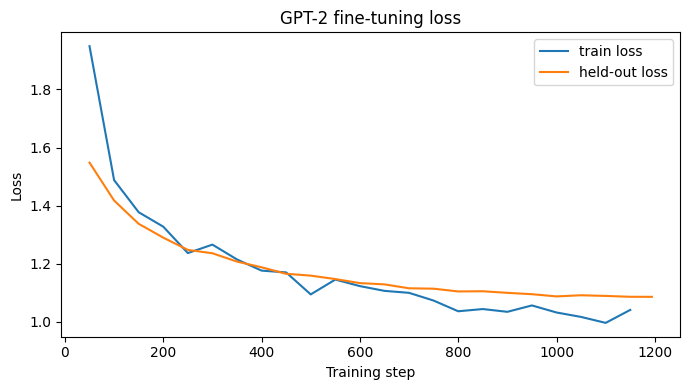

Saved to finetune_curve.png for the report.


In [8]:
logs = trainer.state.log_history
train_steps = [l["step"] for l in logs if "loss" in l and "eval_loss" not in l]
train_losses = [l["loss"] for l in logs if "loss" in l and "eval_loss" not in l]
eval_steps = [l["step"] for l in logs if "eval_loss" in l]
eval_losses = [l["eval_loss"] for l in logs if "eval_loss" in l]

plt.figure(figsize=(7, 4))
plt.plot(train_steps, train_losses, label="train loss")
plt.plot(eval_steps, eval_losses, label="held-out loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GPT-2 fine-tuning loss")
plt.legend()
plt.tight_layout()
plt.savefig("finetune_curve.png", dpi=150)
plt.show()
print("Saved to finetune_curve.png for the report.")


## Constrained decoding

Building a list of every GPT-2 vocabulary token that's made up *only* of characters that
actually appear in real ABC notation tunes. Anything outside that list (random English
words, unrelated symbols GPT-2 might otherwise be tempted to use) gets blocked during
generation by setting its score to -infinity before sampling — so the model is structurally
prevented from drifting off into non-music text.


In [9]:
abc_chars = set(text)   # every character that legitimately shows up in the real dataset

vocab = tokenizer.get_vocab()
allowed_token_ids = []
for token_str, token_id in vocab.items():
    decoded = tokenizer.convert_tokens_to_string([token_str])
    if decoded != "" and all(ch in abc_chars for ch in decoded):
        allowed_token_ids.append(token_id)

allowed_token_ids = set(allowed_token_ids) | {tokenizer.eos_token_id}
print(f"Allowed tokens: {len(allowed_token_ids)} out of {len(vocab)} total GPT-2 tokens")


class ABCOnlyLogitsProcessor(LogitsProcessor):
    # Blocks every token that isn't built purely from valid ABC-notation characters.
    def __init__(self, allowed_token_ids, vocab_size):
        mask = torch.full((vocab_size,), float("-inf"))
        mask[list(allowed_token_ids)] = 0.0
        self.mask = mask

    def __call__(self, input_ids, scores):
        return scores + self.mask.to(scores.device)


Allowed tokens: 5459 out of 50257 total GPT-2 tokens


## Generating tunes — with and without the constraint

Comparing both so the report can show whether constrained decoding actually made a visible
difference, not just assuming it did.


In [10]:
prompt = "M:4/4\nK:G\n"
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

print("=== Unconstrained generation ===")
output = model.generate(
    input_ids,
    max_new_tokens=150,
    do_sample=True,
    temperature=0.5,
    top_k=50,
    pad_token_id=tokenizer.eos_token_id,
)
print(tokenizer.decode(output[0], skip_special_tokens=True))

print("\n=== Constrained generation (ABC characters only) ===")
logits_processor = LogitsProcessorList([
    ABCOnlyLogitsProcessor(allowed_token_ids, model.config.vocab_size)
])
output_constrained = model.generate(
    input_ids,
    max_new_tokens=150,
    do_sample=True,
    temperature=0.5,
    top_k=50,
    logits_processor=logits_processor,
    pad_token_id=tokenizer.eos_token_id,
)
print(tokenizer.decode(output_constrained[0], skip_special_tokens=True))


=== Unconstrained generation ===
M:4/4
K:G
d|g2g gec|B2G BAG|B2G BAG|B2G BAG|B2G BAG|
g2g gec|B2G BAG|B2G BAG|B2G BAG|B2G BAG|B2G BAG|
B2G BAG|B2G BAG|B2G BAG|B2G BAG|B2G BAG|B2G BAG|B2G BAG|B2G BAG|
B2G BAG|B2G BAG|B2G BAG|B2G BAG|B2G BAG|B

=== Constrained generation (ABC characters only) ===
M:4/4
K:G
D|G2G B2G|A2A A2B|c2c c2c|d2d B2G|A2A A2B|
c2c c2c|d2d B2G|A2A A2B|c2c c2c|d2d B2G|A2A A2B|
c2c c2c|d2d B2G|A2A A2B|c2c c2c|d2d B2G|A2A A2B|c2c c2c|d2d B2G|A2A A2B|
c2c c2


In [ ]:
# ================================================================
# Enhanced loss curve — epoch markers + perplexity annotation
# More readable than the basic matplotlib version.
# ================================================================
import plotly.graph_objects as go

fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(
    x=train_steps, y=train_losses,
    mode="lines+markers", name="Train loss",
    line=dict(color="#2563EB", width=2),
    marker=dict(size=4),
    hovertemplate="Step %{x}<br>Train loss: %{y:.3f}<extra></extra>",
))
fig_loss.add_trace(go.Scatter(
    x=eval_steps, y=eval_losses,
    mode="lines+markers", name="Held-out loss",
    line=dict(color="#D94F3D", width=2.5, dash="dash"),
    marker=dict(size=6, symbol="circle-open"),
    hovertemplate="Step %{x}<br>Eval loss: %{y:.3f}<extra></extra>",
))

# Mark approximate epoch boundaries (199 steps per epoch with batch_size=4, 793 samples)
steps_per_epoch = len(train_ds) // training_args.per_device_train_batch_size
for ep in range(1, int(training_args.num_train_epochs) + 1):
    fig_loss.add_vline(
        x=ep * steps_per_epoch,
        line_dash="dot", line_color="#9ca3af",
        annotation_text=f"Epoch {ep}",
        annotation_font_size=10,
    )

# Annotate final perplexity
final_ppl = math.exp(eval_losses[-1]) if eval_losses else perplexity
fig_loss.add_annotation(
    x=eval_steps[-1], y=eval_losses[-1],
    text=f"PPL = {final_ppl:.2f}",
    showarrow=True, arrowhead=2,
    font=dict(color="#D94F3D", size=12),
    bgcolor="white", bordercolor="#D94F3D",
)

fig_loss.update_layout(
    title="GPT-2 Fine-Tuning Loss (train vs held-out, with epoch markers)",
    xaxis_title="Training step",
    yaxis_title="Cross-entropy loss",
    template="plotly_white",
    height=480,
    legend=dict(orientation="h", y=1.05),
    hovermode="x unified",
)
fig_loss.show()
print(f"Final held-out perplexity: {final_ppl:.2f}  "
      f"(model is surprised by <{final_ppl:.1f} tokens per step on unseen ABC music)")


In [ ]:
# ================================================================
# Quantitative comparison — constrained vs unconstrained generation
# Metrics: unique bigrams, ABC validity, character distribution
# ================================================================
import collections

unconstrained_text = tokenizer.decode(output[0], skip_special_tokens=True)
constrained_text   = tokenizer.decode(output_constrained[0], skip_special_tokens=True)

def abc_metrics(txt):
    note_chars = set("ABCDEFGabcdefg")
    chars = list(txt)
    bigrams = [txt[i:i+2] for i in range(len(txt) - 1)]
    unique_bigrams = len(set(bigrams))
    note_count = sum(c in note_chars for c in chars)
    non_abc = sum(c not in abc_chars for c in chars)
    has_meter  = "M:" in txt
    has_key    = "K:" in txt
    has_repeat = ":|" in txt or "|:" in txt
    return {
        "length": len(txt),
        "unique_bigrams": unique_bigrams,
        "note_density": round(note_count / max(len(chars), 1), 3),
        "non_abc_chars": non_abc,
        "has_meter": has_meter,
        "has_key": has_key,
        "has_repeat": has_repeat,
    }

u_m = abc_metrics(unconstrained_text)
c_m = abc_metrics(constrained_text)

print("=" * 58)
print(f"{'Metric':<22} {'Unconstrained':>16} {'Constrained':>16}")
print("-" * 58)
for key in u_m:
    print(f"{key:<22} {str(u_m[key]):>16} {str(c_m[key]):>16}")
print("=" * 58)

# Character frequency comparison plot
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def char_freq(txt, top_n=20):
    cnt = collections.Counter(txt)
    return zip(*cnt.most_common(top_n))

u_chars, u_counts = char_freq(unconstrained_text)
c_chars, c_counts = char_freq(constrained_text)

fig_cmp = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Unconstrained — top-20 characters", "Constrained — top-20 characters"),
)
fig_cmp.add_trace(
    go.Bar(x=list(u_chars), y=list(u_counts), marker_color="#D94F3D",
           name="Unconstrained",
           hovertemplate="Char '%{x}'<br>Count: %{y}<extra></extra>"),
    row=1, col=1,
)
fig_cmp.add_trace(
    go.Bar(x=list(c_chars), y=list(c_counts), marker_color="#2563EB",
           name="Constrained",
           hovertemplate="Char '%{x}'<br>Count: %{y}<extra></extra>"),
    row=1, col=2,
)
fig_cmp.update_layout(
    title="Character Distribution: Constrained vs Unconstrained Generation",
    height=420,
    template="plotly_white",
    showlegend=False,
)
fig_cmp.update_xaxes(title_text="Character", row=1, col=1)
fig_cmp.update_xaxes(title_text="Character", row=1, col=2)
fig_cmp.update_yaxes(title_text="Frequency", row=1, col=1)
fig_cmp.show()

# Vocabulary scope summary
print(f"\nConstrained vocab size: {len(allowed_token_ids):,} / {len(vocab):,} GPT-2 tokens "
      f"({100*len(allowed_token_ids)/len(vocab):.1f}% of vocabulary)")
print(f"Non-ABC characters in unconstrained output: {u_m['non_abc_chars']}")
print(f"Non-ABC characters in constrained output:   {c_m['non_abc_chars']}")
